In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATA_DIR   = 'dataset'
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
# ── Style ─────────────────────────────────────────────────────────
BG      = '#0D0F14'
PANEL   = '#13161E'
ACCENT1 = '#00D4FF'
ACCENT2 = '#FF6B35'
ACCENT3 = '#7B61FF'
ACCENT4 = '#39FF14'
MUTED   = '#3A4258'
TEXT    = '#E2E8F0'
SUBTEXT = '#718096'
GROUP_COLORS = {1: ACCENT1, 2: ACCENT2, 3: ACCENT3, 4: ACCENT4}
 
plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    PANEL,
    'axes.edgecolor':    MUTED,
    'axes.labelcolor':   TEXT,
    'axes.titlecolor':   TEXT,
    'xtick.color':       SUBTEXT,
    'ytick.color':       SUBTEXT,
    'text.color':        TEXT,
    'grid.color':        MUTED,
    'grid.alpha':        0.3,
    'font.family':       'monospace',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        130,
})
 
def save(fig, name):
    path = os.path.join(OUTPUT_DIR, f'{name}.png')
    fig.savefig(path, bbox_inches='tight', facecolor=BG)
    plt.close(fig)
    print(f'  ✓  {path}')

In [4]:
# LOAD

X_train = pd.read_csv(os.path.join(DATA_DIR, 'X_train.csv'), index_col='ROW_ID')
y_train = pd.read_csv(os.path.join(DATA_DIR, 'y_train.csv'), index_col='ROW_ID')
X_test  = pd.read_csv(os.path.join(DATA_DIR, 'X_test.csv'),  index_col='ROW_ID')
 
train = X_train.copy()
train['TARGET'] = y_train.iloc[:, 0]
train['LABEL']  = (train['TARGET'] > 0).astype(int)
 
ret_cols = [f'RET_{i}'           for i in range(1, 21)]
vol_cols = [f'SIGNED_VOLUME_{i}' for i in range(1, 21)]
 
print(f'  Train : {train.shape}')
print(f'  Test  : {X_test.shape}')

  Train : (527073, 46)
  Test  : (31870, 44)


In [5]:
# ═══════════════════════════════════════════════════════════════════
# CLEANUP
# ═══════════════════════════════════════════════════════════════════

 
# Drop SIGNED_VOLUME_1 — 73% missing, unusable
for df in [train, X_train, X_test]:
    df.drop(columns=['SIGNED_VOLUME_1'], inplace=True, errors='ignore')
 
vol_cols_clean = [f'SIGNED_VOLUME_{i}' for i in range(2, 21)]
 
# Fill boundary NaNs in RET and SIGNED_VOLUME with 0
# (these are edge effects from the 20-day window at series start, not true gaps)
for df in [train, X_train, X_test]:
    sv_present = [c for c in vol_cols_clean if c in df.columns]
    df[ret_cols]  = df[ret_cols].fillna(0)
    df[sv_present] = df[sv_present].fillna(0)
 
mdt_median = train['MEDIAN_DAILY_TURNOVER'].median()
for df in [train, X_train, X_test]:
    df['MEDIAN_DAILY_TURNOVER'] = df['MEDIAN_DAILY_TURNOVER'].fillna(mdt_median)
 
# Derived columns used in plots
train['ret_vol']  = train[ret_cols].std(axis=1)
train['ret_mean'] = train[ret_cols].mean(axis=1)
 
print(f'  Remaining missing: {train.isnull().sum().sum()}')

  Remaining missing: 0


In [6]:
# ═══════════════════════════════════════════════════════════════════
# FIG 1 — DATASET OVERVIEW
# ═══════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 9), facecolor=BG)
fig.suptitle('FIG 1  ·  DATASET OVERVIEW',
             fontsize=13, fontweight='bold', color=ACCENT1, y=0.99)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.55, wspace=0.45)
 
# 1a. Train vs test size
ax = fig.add_subplot(gs[0, 0])
sizes  = [len(train), len(X_test)]
labels = ['TRAIN', 'TEST']
bars = ax.bar(labels, sizes, color=[ACCENT1, ACCENT2], width=0.45, edgecolor='none')
ax.set_title('DATASET SIZE', fontsize=9, color=SUBTEXT, pad=6)
ax.set_ylabel('Observations', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.grid(axis='y', alpha=0.2)
for bar, val in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'{val:,}', ha='center', va='bottom', fontsize=7, color=TEXT)
 
# 1b. Group distribution (train)
ax = fig.add_subplot(gs[0, 1])
gc = train['GROUP'].value_counts().sort_index()
colors = [GROUP_COLORS.get(g, MUTED) for g in gc.index]
bars = ax.bar([f'G{g}' for g in gc.index], gc.values, color=colors, edgecolor='none')
ax.set_title('GROUP DISTRIBUTION (TRAIN)', fontsize=9, color=SUBTEXT, pad=6)
ax.set_ylabel('Count', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.grid(axis='y', alpha=0.2)
for bar, val in zip(bars, gc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'{val/1e3:.0f}k', ha='center', va='bottom', fontsize=7, color=SUBTEXT)
 
# 1c. Class balance overall
ax = fig.add_subplot(gs[0, 2])
cb = train['LABEL'].value_counts().sort_index()
wedges, texts, autotexts = ax.pie(
    cb.values, labels=['NEG (0)', 'POS (1)'],
    colors=[ACCENT2, ACCENT1],
    autopct='%1.1f%%',
    textprops={'fontsize': 8, 'color': TEXT},
    wedgeprops={'edgecolor': BG, 'linewidth': 2},
    startangle=90)
for at in autotexts:
    at.set_color(BG); at.set_fontweight('bold')
ax.set_title('CLASS BALANCE', fontsize=9, color=SUBTEXT, pad=6)
 
# 1d. % positive label by group
ax = fig.add_subplot(gs[0, 3])
cb_group = train.groupby('GROUP')['LABEL'].mean()
bars = ax.bar([f'G{g}' for g in cb_group.index],
              cb_group.values * 100,
              color=[GROUP_COLORS.get(g, MUTED) for g in cb_group.index],
              edgecolor='none')
ax.axhline(50, color=TEXT, linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('% POSITIVE LABEL BY GROUP', fontsize=9, color=SUBTEXT, pad=6)
ax.set_ylabel('% Positive', fontsize=8)
ax.set_ylim(48, 53)
ax.grid(axis='y', alpha=0.2)
for bar, val in zip(bars, cb_group.values):
    ax.text(bar.get_x() + bar.get_width()/2, val*100 + 0.05,
            f'{val*100:.2f}%', ha='center', va='bottom', fontsize=7, color=TEXT)
 
# 1e. Target distribution
ax = fig.add_subplot(gs[1, :2])
clipped = train['TARGET'].clip(
    train['TARGET'].quantile(0.005),
    train['TARGET'].quantile(0.995))
ax.hist(clipped, bins=300, color=ACCENT1, alpha=0.85, edgecolor='none')
ax.axvline(0, color=ACCENT2, linewidth=1.2, linestyle='--', label='zero')
ax.set_title('TARGET DISTRIBUTION  (0.5%–99.5% clipped)', fontsize=9, color=SUBTEXT, pad=6)
ax.set_xlabel('Next-day return', fontsize=8)
ax.set_ylabel('Count', fontsize=8)
ax.grid(axis='y', alpha=0.2)
stats = train['TARGET'].describe()
ax.text(0.98, 0.92,
        f"mean={stats['mean']:.5f}  std={stats['std']:.4f}\n"
        f"min={stats['min']:.4f}    max={stats['max']:.4f}",
        transform=ax.transAxes, ha='right', va='top', fontsize=7, color=SUBTEXT,
        bbox=dict(boxstyle='round,pad=0.3', facecolor=BG, edgecolor=MUTED))
 
# 1f. Target distribution by group
ax = fig.add_subplot(gs[1, 2:])
for g, col in GROUP_COLORS.items():
    sub = train[train['GROUP'] == g]['TARGET'].clip(
        train['TARGET'].quantile(0.005),
        train['TARGET'].quantile(0.995))
    ax.hist(sub, bins=150, alpha=0.5, color=col, label=f'G{g}', edgecolor='none')
ax.axvline(0, color=TEXT, linewidth=1, linestyle='--', alpha=0.6)
ax.set_title('TARGET DISTRIBUTION BY GROUP', fontsize=9, color=SUBTEXT, pad=6)
ax.set_xlabel('Next-day return', fontsize=8)
ax.set_ylabel('Count', fontsize=8)
ax.legend(fontsize=7, framealpha=0.2)
ax.grid(axis='y', alpha=0.2)
 
save(fig, 'fig1_dataset_overview')
 
 


  ✓  outputs/fig1_dataset_overview.png


In [7]:
# ═══════════════════════════════════════════════════════════════════
# FIG 2 — MISSING VALUES (pre-cleanup, recomputed from raw)
# ═══════════════════════════════════════════════════════════════════

 
# Reload raw to show original missingness
X_train_raw = pd.read_csv(os.path.join(DATA_DIR, 'X_train.csv'), index_col='ROW_ID')
X_test_raw  = pd.read_csv(os.path.join(DATA_DIR, 'X_test.csv'),  index_col='ROW_ID')
 
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=BG)
fig.suptitle('FIG 2  ·  MISSING VALUES  (raw, before cleanup)',
             fontsize=13, fontweight='bold', color=ACCENT1, y=1.01)
 
for ax, (df, title) in zip(axes, [(X_train_raw, 'X_TRAIN'), (X_test_raw, 'X_TEST')]):
    miss_pct = df.isnull().mean() * 100
    miss_pct = miss_pct[miss_pct > 0].sort_values()
    bar_colors = [ACCENT2 if p > 50 else ACCENT3 if p > 5 else ACCENT1
                  for p in miss_pct]
    ax.barh(range(len(miss_pct)), miss_pct.values, color=bar_colors, edgecolor='none')
    ax.set_yticks(range(len(miss_pct)))
    ax.set_yticklabels(
        [c.replace('SIGNED_VOLUME_', 'SV_').replace('RET_', 'R_')
         for c in miss_pct.index], fontsize=7)
    ax.set_xlabel('% Missing', fontsize=8)
    ax.set_title(title, fontsize=10, color=TEXT, pad=8)
    ax.axvline(5,  color=ACCENT3, linestyle=':', linewidth=1, alpha=0.7, label='>5%')
    ax.axvline(50, color=ACCENT2, linestyle=':', linewidth=1, alpha=0.7, label='>50%')
    ax.legend(fontsize=7, framealpha=0.2)
    ax.grid(axis='x', alpha=0.2)
    for i, val in enumerate(miss_pct.values):
        ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=6, color=SUBTEXT)
 
plt.tight_layout()
save(fig, 'fig2_missing_values')
 
 


  ✓  outputs/fig2_missing_values.png


In [8]:
# ═══════════════════════════════════════════════════════════════════
# FIG 3 — RETURN SERIES
# ═══════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 10), facecolor=BG)
fig.suptitle('FIG 3  ·  RETURN SERIES  (RET_1 = most recent … RET_20 = oldest)',
             fontsize=13, fontweight='bold', color=ACCENT1, y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4)
 
lags = list(range(1, 21))
 
# 3a. Boxplot per lag
ax = fig.add_subplot(gs[0, :2])
ret_data = [train[c].dropna() for c in ret_cols]
bp = ax.boxplot(ret_data, patch_artist=True, showfliers=False,
                medianprops=dict(color=ACCENT2, linewidth=1.5),
                whiskerprops=dict(color=MUTED),
                capprops=dict(color=MUTED),
                boxprops=dict(linewidth=0.8))
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(ACCENT1)
    patch.set_alpha(0.3 + 0.5 * (i / 20))
    patch.set_edgecolor(MUTED)
ax.set_xticks(range(1, 21))
ax.set_xticklabels([str(i) for i in lags], fontsize=7)
ax.set_xlabel('Lag  (1 = most recent)', fontsize=8)
ax.set_ylabel('Return', fontsize=8)
ax.set_title('RETURN DISTRIBUTION PER LAG  (outliers hidden)', fontsize=9, color=SUBTEXT, pad=6)
ax.axhline(0, color=TEXT, linewidth=0.6, linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.2)
 
# 3b. Mean |return| by lag
ax = fig.add_subplot(gs[0, 2])
mean_abs = [train[c].abs().mean() for c in ret_cols]
ax.plot(lags, mean_abs, color=ACCENT1, linewidth=1.5, marker='o',
        markersize=4, markerfacecolor=ACCENT2)
ax.set_xlabel('Lag', fontsize=8)
ax.set_ylabel('Mean |RET|', fontsize=8)
ax.set_title('MEAN |RETURN| BY LAG', fontsize=9, color=SUBTEXT, pad=6)
ax.grid(alpha=0.2)
 
# 3c. Correlation of each lag with TARGET
ax = fig.add_subplot(gs[1, :2])
corrs = [train[c].corr(train['TARGET']) for c in ret_cols]
bar_colors = [ACCENT1 if c > 0 else ACCENT2 for c in corrs]
ax.bar(lags, corrs, color=bar_colors, edgecolor='none')
ax.axhline(0, color=TEXT, linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_xticks(lags)
ax.set_xticklabels([str(i) for i in lags], fontsize=7)
ax.set_xlabel('Lag  (1 = most recent)', fontsize=8)
ax.set_ylabel('Pearson correlation', fontsize=8)
ax.set_title('CORRELATION: RET_i  ↔  TARGET', fontsize=9, color=SUBTEXT, pad=6)
ax.grid(axis='y', alpha=0.2)
for x, val in zip(lags, corrs):
    ax.text(x, val + (0.001 if val >= 0 else -0.003),
            f'{val:.3f}', ha='center',
            va='bottom' if val >= 0 else 'top',
            fontsize=5.5, color=TEXT, rotation=90)
 
# 3d. RET_1 split by label
ax = fig.add_subplot(gs[1, 2])
for label, col, name in [(1, ACCENT1, 'POS (1)'), (0, ACCENT2, 'NEG (0)')]:
    sub = train[train['LABEL'] == label]['RET_1'].clip(-0.02, 0.02)
    ax.hist(sub, bins=100, alpha=0.6, color=col, label=name,
            edgecolor='none', density=True)
ax.set_xlabel('RET_1', fontsize=8)
ax.set_ylabel('Density', fontsize=8)
ax.set_title('RET_1 SPLIT BY TARGET LABEL', fontsize=9, color=SUBTEXT, pad=6)
ax.legend(fontsize=7, framealpha=0.2)
ax.grid(alpha=0.2)
 
save(fig, 'fig3_return_series')
 
 


  ✓  outputs/fig3_return_series.png


In [9]:
# ═══════════════════════════════════════════════════════════════════
# FIG 4 — SIGNED VOLUME SERIES
# ═══════════════════════════════════════════════════════════════════

vol_cols_plot = [f'SIGNED_VOLUME_{i}' for i in range(2, 21)]
lags_v = list(range(2, 21))
 
fig = plt.figure(figsize=(18, 10), facecolor=BG)
fig.suptitle('FIG 4  ·  SIGNED VOLUME  (lag 1 dropped — 73% missing)',
             fontsize=13, fontweight='bold', color=ACCENT1, y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4)
 
# 4a. Boxplot per lag
ax = fig.add_subplot(gs[0, :2])
vol_data = [train[c].dropna() for c in vol_cols_plot]
bp = ax.boxplot(vol_data, patch_artist=True, showfliers=False,
                medianprops=dict(color=ACCENT2, linewidth=1.5),
                whiskerprops=dict(color=MUTED),
                capprops=dict(color=MUTED),
                boxprops=dict(linewidth=0.8))
for patch in bp['boxes']:
    patch.set_facecolor(ACCENT3)
    patch.set_alpha(0.5)
    patch.set_edgecolor(MUTED)
ax.set_xticks(range(1, len(vol_cols_plot) + 1))
ax.set_xticklabels([str(i) for i in lags_v], fontsize=7)
ax.set_xlabel('Lag  (2 = most recent usable)', fontsize=8)
ax.set_ylabel('Signed Volume', fontsize=8)
ax.set_title('SIGNED VOLUME DISTRIBUTION PER LAG  (outliers hidden)', fontsize=9, color=SUBTEXT, pad=6)
ax.axhline(0, color=TEXT, linewidth=0.6, linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.2)
 
# 4b. % positive by lag
ax = fig.add_subplot(gs[0, 2])
pct_pos = [(train[c] > 0).mean() * 100 for c in vol_cols_plot]
ax.plot(lags_v, pct_pos, color=ACCENT3, linewidth=1.5, marker='o',
        markersize=4, markerfacecolor=ACCENT1)
ax.axhline(50, color=TEXT, linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Lag', fontsize=8)
ax.set_ylabel('% Positive', fontsize=8)
ax.set_title('% POSITIVE SIGNED VOLUME BY LAG', fontsize=9, color=SUBTEXT, pad=6)
ax.set_ylim(45, 55)
ax.grid(alpha=0.2)
 
# 4c. Correlation with TARGET
ax = fig.add_subplot(gs[1, :2])
corrs_v = [train[c].corr(train['TARGET']) for c in vol_cols_plot]
bar_colors_v = [ACCENT3 if c > 0 else ACCENT2 for c in corrs_v]
ax.bar(lags_v, corrs_v, color=bar_colors_v, edgecolor='none')
ax.axhline(0, color=TEXT, linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_xticks(lags_v)
ax.set_xticklabels([str(i) for i in lags_v], fontsize=7)
ax.set_xlabel('Lag', fontsize=8)
ax.set_ylabel('Pearson correlation', fontsize=8)
ax.set_title('CORRELATION: SIGNED_VOLUME_i  ↔  TARGET', fontsize=9, color=SUBTEXT, pad=6)
ax.grid(axis='y', alpha=0.2)
 
# 4d. SV_2 split by label
ax = fig.add_subplot(gs[1, 2])
for label, col, name in [(1, ACCENT1, 'POS (1)'), (0, ACCENT2, 'NEG (0)')]:
    sub = train[train['LABEL'] == label]['SIGNED_VOLUME_2']
    sub = sub.clip(sub.quantile(0.01), sub.quantile(0.99))
    ax.hist(sub, bins=80, alpha=0.6, color=col, label=name,
            edgecolor='none', density=True)
ax.set_xlabel('SIGNED_VOLUME_2', fontsize=8)
ax.set_ylabel('Density', fontsize=8)
ax.set_title('SV_2 SPLIT BY TARGET LABEL', fontsize=9, color=SUBTEXT, pad=6)
ax.legend(fontsize=7, framealpha=0.2)
ax.grid(alpha=0.2)
 
save(fig, 'fig4_signed_volume')
 
 


  ✓  outputs/fig4_signed_volume.png


In [10]:
# ═══════════════════════════════════════════════════════════════════
# FIG 5 — TURNOVER & GROUP
# ═══════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 9), facecolor=BG)
fig.suptitle('FIG 5  ·  TURNOVER & GROUP ANALYSIS',
             fontsize=13, fontweight='bold', color=ACCENT1, y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4)
 
# 5a. Turnover distribution (log scale)
ax = fig.add_subplot(gs[0, 0])
ax.hist(np.log1p(train['MEDIAN_DAILY_TURNOVER'].dropna()),
        bins=100, color=ACCENT4, alpha=0.8, edgecolor='none')
ax.set_xlabel('log(1 + MDT)', fontsize=8)
ax.set_ylabel('Count', fontsize=8)
ax.set_title('TURNOVER DISTRIBUTION  (log scale)', fontsize=9, color=SUBTEXT, pad=6)
ax.grid(axis='y', alpha=0.2)
 
# 5b. Turnover by group
ax = fig.add_subplot(gs[0, 1])
for g, col in GROUP_COLORS.items():
    sub = np.log1p(train[train['GROUP'] == g]['MEDIAN_DAILY_TURNOVER'].dropna())
    ax.hist(sub, bins=80, alpha=0.5, color=col, label=f'G{g}',
            edgecolor='none', density=True)
ax.set_xlabel('log(1 + MDT)', fontsize=8)
ax.set_ylabel('Density', fontsize=8)
ax.set_title('TURNOVER BY GROUP', fontsize=9, color=SUBTEXT, pad=6)
ax.legend(fontsize=7, framealpha=0.2)
ax.grid(alpha=0.2)
 
# 5c. Turnover boxplot by group
ax = fig.add_subplot(gs[0, 2])
data_by_group = [np.log1p(train[train['GROUP'] == g]['MEDIAN_DAILY_TURNOVER'].dropna())
                 for g in sorted(GROUP_COLORS)]
bp = ax.boxplot(data_by_group, patch_artist=True, showfliers=False,
                medianprops=dict(color=BG, linewidth=2),
                whiskerprops=dict(color=MUTED),
                capprops=dict(color=MUTED))
for patch, col in zip(bp['boxes'], GROUP_COLORS.values()):
    patch.set_facecolor(col); patch.set_alpha(0.7); patch.set_edgecolor(MUTED)
ax.set_xticklabels([f'G{g}' for g in sorted(GROUP_COLORS)], fontsize=8)
ax.set_ylabel('log(1 + MDT)', fontsize=8)
ax.set_title('TURNOVER BOXPLOT BY GROUP', fontsize=9, color=SUBTEXT, pad=6)
ax.grid(axis='y', alpha=0.2)
 
# 5d. Intra-window return vol by group
ax = fig.add_subplot(gs[1, 0])
for g, col in GROUP_COLORS.items():
    sub = train[train['GROUP'] == g]['ret_vol']
    sub = sub.clip(0, sub.quantile(0.99))
    ax.hist(sub, bins=80, alpha=0.5, color=col, label=f'G{g}',
            edgecolor='none', density=True)
ax.set_xlabel('Std(RET_1…RET_20)', fontsize=8)
ax.set_ylabel('Density', fontsize=8)
ax.set_title('INTRA-WINDOW RETURN VOL BY GROUP', fontsize=9, color=SUBTEXT, pad=6)
ax.legend(fontsize=7, framealpha=0.2)
ax.grid(alpha=0.2)
 
# 5e. Mean window return by group
ax = fig.add_subplot(gs[1, 1])
for g, col in GROUP_COLORS.items():
    sub = train[train['GROUP'] == g]['ret_mean']
    sub = sub.clip(sub.quantile(0.01), sub.quantile(0.99))
    ax.hist(sub, bins=80, alpha=0.5, color=col, label=f'G{g}',
            edgecolor='none', density=True)
ax.axvline(0, color=TEXT, linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Mean(RET_1…RET_20)', fontsize=8)
ax.set_ylabel('Density', fontsize=8)
ax.set_title('MEAN WINDOW RETURN BY GROUP', fontsize=9, color=SUBTEXT, pad=6)
ax.legend(fontsize=7, framealpha=0.2)
ax.grid(alpha=0.2)
 
# 5f. Group distribution in TEST
ax = fig.add_subplot(gs[1, 2])
gc_test = X_test['GROUP'].value_counts().sort_index()
bars = ax.bar([f'G{g}' for g in gc_test.index], gc_test.values,
              color=[GROUP_COLORS.get(g, MUTED) for g in gc_test.index],
              edgecolor='none')
ax.set_title('GROUP DISTRIBUTION  (TEST)', fontsize=9, color=SUBTEXT, pad=6)
ax.set_ylabel('Count', fontsize=8)
ax.grid(axis='y', alpha=0.2)
for bar, val in zip(bars, gc_test.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'{val:,}', ha='center', va='bottom', fontsize=7, color=TEXT)
 
save(fig, 'fig5_turnover_group')
 
 


  ✓  outputs/fig5_turnover_group.png


In [11]:
# ═══════════════════════════════════════════════════════════════════
# FIG 6 — CORRELATION HEATMAP
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor=BG)
fig.suptitle('FIG 6  ·  CROSS-FEATURE CORRELATION  (key features)',
             fontsize=13, fontweight='bold', color=ACCENT1, y=1.01)
 
cmap = sns.diverging_palette(220, 20, as_cmap=True)
key_cols = (
    [f'RET_{i}' for i in [1, 2, 3, 5, 10, 20]] +
    [f'SIGNED_VOLUME_{i}' for i in [2, 5, 10]] +
    ['MEDIAN_DAILY_TURNOVER', 'ret_vol', 'ret_mean', 'TARGET']
)
key_cols = [c for c in key_cols if c in train.columns]
 
for ax, (group_filter, title) in zip(axes, [(None, 'ALL GROUPS'), (1, 'GROUP 1')]):
    subset = train if group_filter is None else train[train['GROUP'] == group_filter]
    sample = subset.sample(min(50_000, len(subset)), random_state=42)
    corr = sample[key_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, ax=ax, mask=mask, cmap=cmap, center=0,
                vmin=-0.15, vmax=0.15,
                annot=True, fmt='.2f', annot_kws={'size': 6},
                linewidths=0.3, linecolor=BG,
                cbar_kws={'shrink': 0.7})
    ax.set_title(title, fontsize=10, color=TEXT, pad=8)
    ax.tick_params(labelsize=7)
    ax.set_facecolor(PANEL)
 
plt.tight_layout()
save(fig, 'fig6_correlation_matrix')

  ✓  outputs/fig6_correlation_matrix.png


In [12]:
# ═══════════════════════════════════════════════════════════════════
# SUMMARY
# ═══════════════════════════════════════════════════════════════════
print('\n── CLEANUP SUMMARY ───────────────────────────────────────────')
print('  DROPPED  : SIGNED_VOLUME_1  (73% missing in train, unusable)')
print('  FILLED   : RET_{i} NaNs → 0  (boundary artifacts, max 58 rows)')
print('  FILLED   : SIGNED_VOLUME_{i} NaNs → 0  (boundary + rollup gaps)')
print(f'  FILLED   : MEDIAN_DAILY_TURNOVER NaNs → {mdt_median:.6f}  (median)')
print(f'\n  Remaining missing in train: {train[key_cols].isnull().sum().sum()}')
print(f'  Output PNGs → {OUTPUT_DIR}/')
print('──────────────────────────────────────────────────────────────\n')
 


── CLEANUP SUMMARY ───────────────────────────────────────────
  DROPPED  : SIGNED_VOLUME_1  (73% missing in train, unusable)
  FILLED   : RET_{i} NaNs → 0  (boundary artifacts, max 58 rows)
  FILLED   : SIGNED_VOLUME_{i} NaNs → 0  (boundary + rollup gaps)
  FILLED   : MEDIAN_DAILY_TURNOVER NaNs → 0.015935  (median)

  Remaining missing in train: 0
  Output PNGs → outputs/
──────────────────────────────────────────────────────────────



In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import lightgbm as lgb

In [14]:

# ── Feature engineering ───────────────────────────────────────────
def engineer_features(df, ret_cols):
    d = df.copy()
    
    # Core RET_1 transformations
    d['abs_ret1']        = d['RET_1'].abs()
    d['log_abs_ret1']    = np.log1p(d['RET_1'].abs() * 1000)
    d['ret1_signed_mag'] = np.sign(d['RET_1']) * np.log1p(d['RET_1'].abs() * 1000)
    
    # RET_1 vs RET_2 consistency (momentum confirmation)
    d['ret1_ret2_agree'] = (np.sign(d['RET_1']) == np.sign(d['RET_2'])).astype(int)
    
    # Intra-window stats
    d['ret_vol']  = d[ret_cols].std(axis=1)
    d['ret_mean'] = d[ret_cols].mean(axis=1)
    
    # Turnover (already clean)
    d['log_turnover'] = np.log1p(d['MEDIAN_DAILY_TURNOVER'])
    
    return d

train    = engineer_features(train,   ret_cols)
X_train  = engineer_features(X_train, ret_cols)
X_test   = engineer_features(X_test,  ret_cols)

print("Features added. Train shape:", train.shape)

Features added. Train shape: (527073, 52)


In [15]:
# ── Setup ─────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y  = train['LABEL']

# ── Model 1: RET_1 only ───────────────────────────────────────────
pipe_ret1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])

scores_ret1 = cross_val_score(
    pipe_ret1, train[['RET_1']], y,
    cv=cv, scoring='accuracy'
)

print("── Model 1: Logistic Regression  |  RET_1 only ──────────────")
print(f"  Fold scores : {scores_ret1.round(4)}")
print(f"  Mean        : {scores_ret1.mean():.4f}")
print(f"  Std         : {scores_ret1.std():.4f}")

── Model 1: Logistic Regression  |  RET_1 only ──────────────
  Fold scores : [0.518  0.5209 0.519  0.5203 0.5184]
  Mean        : 0.5193
  Std         : 0.0011


In [16]:
# ── Model 2: RET_1 + engineered features ─────────────────────────
eng_features = [
    'RET_1',
    'ret1_signed_mag',
    'ret1_ret2_agree',
    'abs_ret1',
    'ret_vol',
    'ret_mean',
    'log_turnover',
]

pipe_eng = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])

scores_eng = cross_val_score(
    pipe_eng, train[eng_features], y,
    cv=cv, scoring='accuracy'
)

print("── Model 2: Logistic Regression  |  Engineered features ─────")
print(f"  Fold scores : {scores_eng.round(4)}")
print(f"  Mean        : {scores_eng.mean():.4f}")
print(f"  Std         : {scores_eng.std():.4f}")
print(f"  vs Model 1  : {(scores_eng.mean() - scores_ret1.mean())*100:+.3f}pp")

── Model 2: Logistic Regression  |  Engineered features ─────
  Fold scores : [0.52   0.522  0.5187 0.5211 0.5206]
  Mean        : 0.5205
  Std         : 0.0011
  vs Model 1  : +0.118pp


In [17]:
# ── Model 3: All RET lags + engineered features ───────────────────
all_ret_features = ret_cols + eng_features

pipe_allret = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])

scores_allret = cross_val_score(
    pipe_allret, train[all_ret_features], y,
    cv=cv, scoring='accuracy'
)

print("── Model 3: Logistic Regression  |  All lags + engineered ──")
print(f"  Fold scores : {scores_allret.round(4)}")
print(f"  Mean        : {scores_allret.mean():.4f}")
print(f"  Std         : {scores_allret.std():.4f}")
print(f"  vs Model 2  : {(scores_allret.mean() - scores_eng.mean())*100:+.3f}pp")

── Model 3: Logistic Regression  |  All lags + engineered ──
  Fold scores : [0.5215 0.5234 0.5213 0.5253 0.5229]
  Mean        : 0.5229
  Std         : 0.0014
  vs Model 2  : +0.239pp


In [18]:
from sklearn.model_selection import train_test_split

# ── Model 4: LightGBM  |  Single train/val split ─────────────────
lgbm_features = ret_cols + eng_features + [
    f'SIGNED_VOLUME_{i}' for i in range(2, 21)
] + ['MEDIAN_DAILY_TURNOVER', 'GROUP']

# Deduplicate
seen = set()
lgbm_features = [f for f in lgbm_features if not (f in seen or seen.add(f))]

X_tr, X_val, y_tr, y_val = train_test_split(
    train[lgbm_features], y,
    test_size=0.2, random_state=42, stratify=y
)

model_lgbm = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
    n_jobs=2
)

model_lgbm.fit(X_tr, y_tr)
val_acc = (model_lgbm.predict(X_val) == y_val).mean()

print("── Model 4: LightGBM  |  All features ───────────────────────")
print(f"  Val accuracy : {val_acc:.4f}")
print(f"  vs Model 3   : {(val_acc - scores_allret.mean())*100:+.3f}pp")

── Model 4: LightGBM  |  All features ───────────────────────
  Val accuracy : 0.5435
  vs Model 3   : +2.058pp


── Top 20 features ──────────────────────────────────────────
RET_2           235
ret_mean        225
RET_11          210
RET_4           202
RET_9           200
RET_7           200
RET_10          198
RET_15          197
RET_13          195
RET_8           191
RET_6           190
RET_16          190
log_turnover    189
RET_1           182
RET_3           181
RET_17          180
RET_12          179
RET_14          165
RET_5           164
RET_19          156


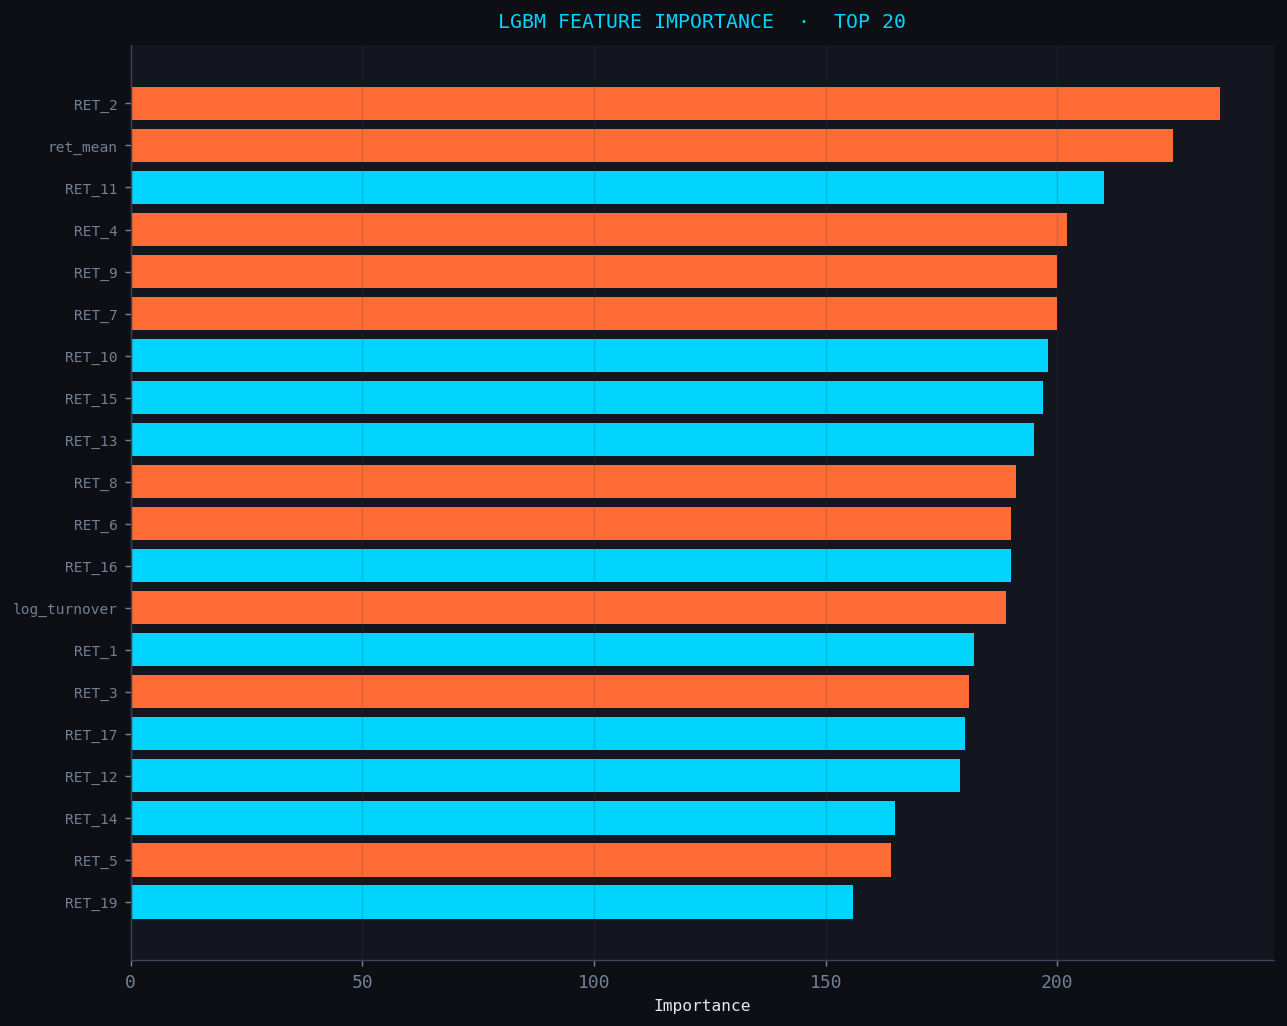

In [19]:
# ── Feature importance ────────────────────────────────────────────
importance = pd.Series(
    model_lgbm.feature_importances_,
    index=lgbm_features
).sort_values(ascending=False)

print("── Top 20 features ──────────────────────────────────────────")
print(importance.head(20).round(1).to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
top20 = importance.head(20)
colors = [ACCENT1 if 'RET_1' in f or f in ['ret1_signed_mag', 'abs_ret1', 'log_abs_ret1']
          else ACCENT3 if 'VOLUME' in f
          else ACCENT2
          for f in top20.index]
ax.barh(range(len(top20)), top20.values[::-1], color=colors[::-1], edgecolor='none')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index[::-1], fontsize=8)
ax.set_xlabel('Importance', fontsize=9)
ax.set_title('LGBM FEATURE IMPORTANCE  ·  TOP 20',
             fontsize=11, color=ACCENT1, pad=10)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('outputs/fig7_feature_importance.png',
            bbox_inches='tight', facecolor=BG)
plt.show()

In [20]:
# ── Model 5: LightGBM  |  No volume, cleaner ─────────────────────
clean_features = ret_cols + [
    'ret1_signed_mag',
    'abs_ret1',
    'ret1_ret2_agree',
    'ret_vol',
    'ret_mean',
    'log_turnover',
    'GROUP'
]

X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    train[clean_features], y,
    test_size=0.2, random_state=42, stratify=y
)

model_lgbm2 = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
    n_jobs=2
)

model_lgbm2.fit(X_tr2, y_tr2)
val_acc2 = (model_lgbm2.predict(X_val2) == y_val2).mean()

print("── Model 5: LightGBM  |  No volume ──────────────────────────")
print(f"  Val accuracy : {val_acc2:.4f}")
print(f"  vs Model 4   : {(val_acc2 - val_acc)*100:+.3f}pp")

── Model 5: LightGBM  |  No volume ──────────────────────────
  Val accuracy : 0.5434
  vs Model 4   : -0.011pp


In [21]:
# ── Model 6: Group-specific LightGBM ─────────────────────────────
group_accs = {}
group_models = {}

for g in sorted(train['GROUP'].unique()):
    mask_tr  = X_tr2.index[train.loc[X_tr2.index, 'GROUP'] == g]
    mask_val = X_val2.index[train.loc[X_val2.index, 'GROUP'] == g]

    X_g_tr  = X_tr2.loc[mask_tr,  clean_features]
    y_g_tr  = y_tr2.loc[mask_tr]
    X_g_val = X_val2.loc[mask_val, clean_features]
    y_g_val = y_val2.loc[mask_val]

    m = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
        n_jobs=2
    )
    m.fit(X_g_tr, y_g_tr)
    acc = (m.predict(X_g_val) == y_g_val).mean()
    group_accs[g] = acc
    group_models[g] = m
    print(f"  Group {g} : {acc:.4f}  (n_train={len(X_g_tr):,})")

overall = sum(
    group_accs[g] * (train.loc[X_val2.index, 'GROUP'] == g).sum()
    for g in group_accs
) / len(X_val2)

print(f"\n  Weighted overall : {overall:.4f}")
print(f"  vs Model 5       : {(overall - val_acc2)*100:+.3f}pp")

  Group 1 : 0.5835  (n_train=80,142)
  Group 2 : 0.5523  (n_train=107,999)
  Group 3 : 0.5507  (n_train=134,969)
  Group 4 : 0.5681  (n_train=98,548)

  Weighted overall : 0.5614
  vs Model 5       : +1.802pp


In [22]:
# ── Submission ────────────────────────────────────────────────────
sample_sub = pd.read_csv('dataset/sample_submission.csv', index_col='ROW_ID')

# ── Submission: RET_1 sign only — pure momentum ───────────────────
preds_ret1 = (X_test['RET_1'] > 0).astype(int)

submission = pd.DataFrame(
    {'target': preds_ret1},
    index=X_test.index
)

print("── Submission sanity check ──────────────────────────────────")
print(f"  Value counts : {submission['target'].value_counts().to_dict()}")
print(f"  Index matches: {(submission.index == sample_sub.index).all()}")

submission.to_csv('dataset/submission.csv')
print("\n  Saved → data/submission.csv")

── Submission sanity check ──────────────────────────────────
  Value counts : {1: 16419, 0: 15451}
  Index matches: True

  Saved → data/submission.csv


In [23]:
# ── Check cross-sectional structure ───────────────────────────────
# How many allocations per date?
allocs_per_date = train.groupby('TS').size()
print("Allocations per date:")
print(allocs_per_date.describe())
print(f"\nMin  : {allocs_per_date.min()}")
print(f"Max  : {allocs_per_date.max()}")
print(f"Modal: {allocs_per_date.mode()[0]}")

# Are the same allocations present across dates?
print(f"\nUnique dates      : {train['TS'].nunique()}")
print(f"Unique allocations: {train['ALLOCATION'].nunique()}")
print(f"Total rows        : {len(train)}")
print(f"Expected if balanced: {train['TS'].nunique() * train['ALLOCATION'].nunique()}")

Allocations per date:
count    2522.000000
mean      208.990087
std        81.903327
min        65.000000
25%       140.000000
50%       276.000000
75%       276.000000
max       276.000000
dtype: float64

Min  : 65
Max  : 276
Modal: 276

Unique dates      : 2522
Unique allocations: 278
Total rows        : 527073
Expected if balanced: 701116


In [24]:
# ── Cross-sectional features ───────────────────────────────────────
def add_cross_sectional_features(df):
    d = df.copy()
    
    # Windows to compute cross-sectional stats over
    short_window  = [f'RET_{i}' for i in range(1, 6)]    # last 5 days
    medium_window = [f'RET_{i}' for i in range(1, 11)]   # last 10 days
    full_window   = [f'RET_{i}' for i in range(1, 21)]   # full 20 days

    # Allocation-level window means (already have ret_mean, add shorter ones)
    d['ret_mean_5']  = d[short_window].mean(axis=1)
    d['ret_mean_10'] = d[medium_window].mean(axis=1)

    # Allocation-level volatility over multiple windows
    d['ret_vol_5']  = d[short_window].std(axis=1)
    d['ret_vol_10'] = d[medium_window].std(axis=1)
    d['ret_vol_20'] = d[full_window].std(axis=1)

    # Cross-sectional means per date (market-wide average performance)
    for col, name in [
        ('ret_mean_5',  'xs_mean_ret5'),
        ('ret_mean_10', 'xs_mean_ret10'),
        ('ret_mean',    'xs_mean_ret20'),
        ('ret_vol_5',   'xs_mean_vol5'),
        ('ret_vol_20',  'xs_mean_vol20'),
        ('RET_1',       'xs_mean_ret1'),
    ]:
        xs = d.groupby('TS')[col].transform('mean')
        d[name] = xs

    # Cross-sectional volatility per date (dispersion across allocations)
    for col, name in [
        ('ret_mean_5',  'xs_std_ret5'),
        ('ret_mean',    'xs_std_ret20'),
        ('RET_1',       'xs_std_ret1'),
    ]:
        xs = d.groupby('TS')[col].transform('std')
        d[name] = xs

    # Relative performance — how does this allocation compare to peers on same date
    d['rel_ret1']    = d['RET_1']      - d['xs_mean_ret1']
    d['rel_ret_mean']= d['ret_mean']   - d['xs_mean_ret20']
    d['rel_vol']     = d['ret_vol_20'] - d['xs_mean_vol20']

    return d

train   = add_cross_sectional_features(train)
X_train = add_cross_sectional_features(X_train)
X_test  = add_cross_sectional_features(X_test)

print("Cross-sectional features added. Train shape:", train.shape)

Cross-sectional features added. Train shape: (527073, 69)


In [25]:
# ── Model 7: LightGBM  |  Cross-sectional features ───────────────
xs_features = clean_features + [
    'ret_mean_5', 'ret_mean_10',
    'ret_vol_5', 'ret_vol_10', 'ret_vol_20',
    'xs_mean_ret1', 'xs_mean_ret5', 'xs_mean_ret10', 'xs_mean_ret20',
    'xs_mean_vol5', 'xs_mean_vol20',
    'xs_std_ret1', 'xs_std_ret5', 'xs_std_ret20',
    'rel_ret1', 'rel_ret_mean', 'rel_vol'
]

# Deduplicate
seen = set()
xs_features = [f for f in xs_features if not (f in seen or seen.add(f))]

X_tr3, X_val3, y_tr3, y_val3 = train_test_split(
    train[xs_features], y,
    test_size=0.2, random_state=42, stratify=y
)

model_xs = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
    n_jobs=2
)

model_xs.fit(X_tr3, y_tr3)
val_acc3 = (model_xs.predict(X_val3) == y_val3).mean()

print("── Model 7: LightGBM  |  + Cross-sectional features ────────")
print(f"  Val accuracy : {val_acc3:.4f}")
print(f"  vs Model 5   : {(val_acc3 - val_acc2)*100:+.3f}pp")

── Model 7: LightGBM  |  + Cross-sectional features ────────
  Val accuracy : 0.5720
  vs Model 5   : +2.869pp


In [26]:
# ── Feature importance: Model 7 ───────────────────────────────────
importance_xs = pd.Series(
    model_xs.feature_importances_,
    index=xs_features
).sort_values(ascending=False)

print("── Top 20 features ──────────────────────────────────────────")
print(importance_xs.head(20).round(1).to_string())

── Top 20 features ──────────────────────────────────────────
xs_std_ret1      362
xs_mean_ret20    351
xs_mean_ret5     341
xs_mean_vol20    337
xs_mean_ret1     335
xs_std_ret5      316
xs_std_ret20     310
xs_mean_vol5     306
xs_mean_ret10    295
RET_4            153
RET_2            143
RET_7            134
RET_8            130
log_turnover     124
RET_11           123
GROUP            121
RET_15           115
RET_19           114
RET_18           108
RET_1            107


In [27]:
# ── Submission: Model 7 ───────────────────────────────────────────
model_xs.fit(train[xs_features], y)  # retrain on full dataset

preds_xs = model_xs.predict(X_test[xs_features])

submission = pd.DataFrame(
    {'target': preds_xs},
    index=X_test.index
)

print("── Submission sanity check ──────────────────────────────────")
print(f"  Shape        : {submission.shape}")
print(f"  Missing      : {submission.isnull().sum().sum()}")
print(f"  Value counts : {submission['target'].value_counts().to_dict()}")
print(f"  Index matches: {(submission.index == sample_sub.index).all()}")

submission.to_csv('dataset/submission.csv')
print("\n  Saved → data/submission.csv")

── Submission sanity check ──────────────────────────────────
  Shape        : (31870, 1)
  Missing      : 0
  Value counts : {1: 17815, 0: 14055}
  Index matches: True

  Saved → data/submission.csv


In [28]:
# ── Cross-sectional rank features ────────────────────────────────
def add_rank_features(df):
    d = df.copy()
    
    # Rank of each allocation within its date (0 to 1)
    for col, name in [
        ('RET_1',      'rank_ret1'),
        ('ret_mean_5', 'rank_ret5'),
        ('ret_mean',   'rank_ret20'),
        ('ret_vol_20', 'rank_vol20'),
    ]:
        d[name] = d.groupby('TS')[col].rank(pct=True)
    
    # Same but within GROUP on each date
    for col, name in [
        ('RET_1',      'group_rank_ret1'),
        ('ret_mean',   'group_rank_ret20'),
        ('ret_vol_20', 'group_rank_vol20'),
    ]:
        d[name] = d.groupby(['TS', 'GROUP'])[col].rank(pct=True)
    
    return d

train   = add_rank_features(train)
X_train = add_rank_features(X_train)
X_test  = add_rank_features(X_test)

print("Rank features added. Train shape:", train.shape)

Rank features added. Train shape: (527073, 76)


In [29]:
# ── Model 8: LightGBM  |  + Rank features ────────────────────────
rank_features = xs_features + [
    'rank_ret1', 'rank_ret5', 'rank_ret20', 'rank_vol20',
    'group_rank_ret1', 'group_rank_ret20', 'group_rank_vol20'
]

# Deduplicate
seen = set()
rank_features = [f for f in rank_features if not (f in seen or seen.add(f))]

X_tr4, X_val4, y_tr4, y_val4 = train_test_split(
    train[rank_features], y,
    test_size=0.2, random_state=42, stratify=y
)

model_rank = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
    n_jobs=2
)

model_rank.fit(X_tr4, y_tr4)
val_acc4 = (model_rank.predict(X_val4) == y_val4).mean()

print("── Model 8: LightGBM  |  + Rank features ────────────────────")
print(f"  Val accuracy : {val_acc4:.4f}")
print(f"  vs Model 7   : {(val_acc4 - val_acc3)*100:+.3f}pp")

── Model 8: LightGBM  |  + Rank features ────────────────────
  Val accuracy : 0.5732
  vs Model 7   : +0.120pp


In [30]:
importance_rank = pd.Series(
    model_rank.feature_importances_,
    index=rank_features
).sort_values(ascending=False)

print("── Top 15 features ──────────────────────────────────────────")
print(importance_rank.head(15).round(1).to_string())

── Top 15 features ──────────────────────────────────────────
xs_std_ret1      389
xs_mean_ret20    384
xs_std_ret20     333
xs_mean_ret5     326
xs_std_ret5      316
xs_mean_vol5     314
xs_mean_vol20    313
xs_mean_ret10    298
xs_mean_ret1     278
GROUP            136
RET_6            129
RET_12           123
RET_4            122
log_turnover     120
RET_3            113


In [31]:
# ── Group cross-sectional features ───────────────────────────────
def add_group_xs_features(df):
    d = df.copy()
    
    # Cross-sectional mean/std within GROUP on each date
    for col, name_mean, name_std in [
        ('RET_1',      'gxs_mean_ret1',  'gxs_std_ret1'),
        ('ret_mean_5', 'gxs_mean_ret5',  'gxs_std_ret5'),
        ('ret_mean',   'gxs_mean_ret20', 'gxs_std_ret20'),
        ('ret_vol_20', 'gxs_mean_vol20', 'gxs_std_vol20'),
    ]:
        d[name_mean] = d.groupby(['TS', 'GROUP'])[col].transform('mean')
        d[name_std]  = d.groupby(['TS', 'GROUP'])[col].transform('std')

    # Relative performance within group
    d['grel_ret1']  = d['RET_1']    - d['gxs_mean_ret1']
    d['grel_ret20'] = d['ret_mean'] - d['gxs_mean_ret20']
    d['grel_vol']   = d['ret_vol_20'] - d['gxs_mean_vol20']

    return d

train   = add_group_xs_features(train)
X_train = add_group_xs_features(X_train)
X_test  = add_group_xs_features(X_test)

print("Group XS features added. Train shape:", train.shape)

Group XS features added. Train shape: (527073, 87)


In [32]:
# ── Model 9: LightGBM  |  + Group XS features ────────────────────
all_features = rank_features + [
    'gxs_mean_ret1', 'gxs_std_ret1',
    'gxs_mean_ret5', 'gxs_std_ret5',
    'gxs_mean_ret20', 'gxs_std_ret20',
    'gxs_mean_vol20', 'gxs_std_vol20',
    'grel_ret1', 'grel_ret20', 'grel_vol'
]

# Deduplicate
seen = set()
all_features = [f for f in all_features if not (f in seen or seen.add(f))]

X_tr5, X_val5, y_tr5, y_val5 = train_test_split(
    train[all_features], y,
    test_size=0.2, random_state=42, stratify=y
)

model_full = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
    n_jobs=2
)

model_full.fit(X_tr5, y_tr5)
val_acc5 = (model_full.predict(X_val5) == y_val5).mean()

print("── Model 9: LightGBM  |  Full feature set ───────────────────")
print(f"  Val accuracy : {val_acc5:.4f}")
print(f"  vs Model 8   : {(val_acc5 - val_acc4)*100:+.3f}pp")

── Model 9: LightGBM  |  Full feature set ───────────────────
  Val accuracy : 0.5815
  vs Model 8   : +0.822pp


In [33]:
# ── Submission: Model 9 ───────────────────────────────────────────
model_full.fit(train[all_features], y)  # retrain on full dataset

preds_full = model_full.predict(X_test[all_features])

submission = pd.DataFrame(
    {'target': preds_full},
    index=X_test.index
)

print("── Submission sanity check ──────────────────────────────────")
print(f"  Shape        : {submission.shape}")
print(f"  Missing      : {submission.isnull().sum().sum()}")
print(f"  Value counts : {submission['target'].value_counts().to_dict()}")
print(f"  Index matches: {(submission.index == sample_sub.index).all()}")

submission.to_csv('dataset/submission.csv')
print("\n  Saved → data/submission.csv")

── Submission sanity check ──────────────────────────────────
  Shape        : (31870, 1)
  Missing      : 0
  Value counts : {1: 18320, 0: 13550}
  Index matches: True

  Saved → data/submission.csv


In [34]:

# ── Model 10: Tuned LightGBM  |  XS features only ────────────────
X_tr6, X_val6, y_tr6, y_val6 = train_test_split(
    train[xs_features], y,
    test_size=0.2, random_state=42, stratify=y
)

model_tuned = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.01,       # slower learning
    num_leaves=15,            # shallower trees — less overfit
    min_child_samples=200,    # higher regularisation
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,            # L1
    reg_lambda=0.1,           # L2
    random_state=42,
    verbose=-1,
    n_jobs=2
)

model_tuned.fit(X_tr6, y_tr6)
val_acc6 = (model_tuned.predict(X_val6) == y_val6).mean()

print("── Model 10: Tuned LightGBM  |  XS features ────────────────")
print(f"  Val accuracy : {val_acc6:.4f}")
print(f"  vs Model 7   : {(val_acc6 - val_acc3)*100:+.3f}pp")

── Model 10: Tuned LightGBM  |  XS features ────────────────
  Val accuracy : 0.5432
  vs Model 7   : -2.884pp


In [35]:
# ── Submission: Model 10 ─────────────────────────────────────────
model_tuned.fit(train[xs_features], y)  # retrain on full dataset

preds_tuned = model_tuned.predict(X_test[xs_features])

submission = pd.DataFrame(
    {'target': preds_tuned},
    index=X_test.index
)

print("── Submission sanity check ──────────────────────────────────")
print(f"  Shape        : {submission.shape}")
print(f"  Missing      : {submission.isnull().sum().sum()}")
print(f"  Value counts : {submission['target'].value_counts().to_dict()}")
print(f"  Index matches: {(submission.index == sample_sub.index).all()}")

submission.to_csv('dataset/submission.csv')
print("\n  Saved → data/submission.csv")

── Submission sanity check ──────────────────────────────────
  Shape        : (31870, 1)
  Missing      : 0
  Value counts : {1: 18676, 0: 13194}
  Index matches: True

  Saved → data/submission.csv


In [37]:
# Time-aware split
ts_sorted = sorted(train['TS'].unique())
cutoff = ts_sorted[int(len(ts_sorted) * 0.8)]

train_ts = train[train['TS'] <= cutoff]
val_ts   = train[train['TS'] >  cutoff]

print(f"Train size: {len(train_ts):,}")
print(f"Val size  : {len(val_ts):,}")

Train size: 422,696
Val size  : 104,377


In [38]:
# ── Time-aware validation: Model 7 ───────────────────────────────
model_ts = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
    n_jobs=2
)

model_ts.fit(train_ts[xs_features], train_ts['LABEL'])
val_acc_ts = (model_ts.predict(val_ts[xs_features]) == val_ts['LABEL']).mean()

print("── Model 7: Time-aware validation ───────────────────────────")
print(f"  Val accuracy : {val_acc_ts:.4f}")
print(f"  Leaderboard  : 0.5099  (actual)")
print(f"  Gap          : {(val_acc_ts - 0.5099)*100:+.3f}pp")

── Model 7: Time-aware validation ───────────────────────────
  Val accuracy : 0.5225
  Leaderboard  : 0.5099  (actual)
  Gap          : +1.262pp


In [39]:
# ── Time-aware validation: all models ────────────────────────────
results_ts = {}

configs = {
    'Model 7  — XS features, default':     (xs_features,   dict(n_estimators=200, learning_rate=0.05, num_leaves=31,  min_child_samples=50,  subsample=0.8, colsample_bytree=0.8)),
    'Model 10 — XS features, regularised': (xs_features,   dict(n_estimators=500, learning_rate=0.01, num_leaves=15,  min_child_samples=200, subsample=0.7, colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=0.1)),
    'Model 8  — + rank features':          (rank_features, dict(n_estimators=200, learning_rate=0.05, num_leaves=31,  min_child_samples=50,  subsample=0.8, colsample_bytree=0.8)),
    'Model 9  — + group XS features':      (all_features,  dict(n_estimators=200, learning_rate=0.05, num_leaves=31,  min_child_samples=50,  subsample=0.8, colsample_bytree=0.8)),
}

for name, (feats, params) in configs.items():
    m = lgb.LGBMClassifier(**params, random_state=42, verbose=-1, n_jobs=2)
    m.fit(train_ts[feats], train_ts['LABEL'])
    acc = (m.predict(val_ts[feats]) == val_ts['LABEL']).mean()
    results_ts[name] = acc
    print(f"  {name}: {acc:.4f}")

  Model 7  — XS features, default: 0.5225
  Model 10 — XS features, regularised: 0.5276
  Model 8  — + rank features: 0.5234
  Model 9  — + group XS features: 0.5244


In [40]:
# ── Model 11: More aggressive regularisation ──────────────────────
model_11 = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.005,
    num_leaves=15,
    min_child_samples=500,
    subsample=0.6,
    colsample_bytree=0.6,
    reg_alpha=0.5,
    reg_lambda=0.5,
    random_state=42,
    verbose=-1,
    n_jobs=2
)

model_11.fit(train_ts[xs_features], train_ts['LABEL'])
acc_11 = (model_11.predict(val_ts[xs_features]) == val_ts['LABEL']).mean()

print(f"  Model 11 — aggressive regularisation: {acc_11:.4f}")
print(f"  vs Model 10: {(acc_11 - results_ts['Model 10 — XS features, regularised'])*100:+.3f}pp")

  Model 11 — aggressive regularisation: 0.5254
  vs Model 10: -0.216pp


In [41]:
# ── Submission: Model 10 retrained on full data ───────────────────
model_10_final = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.01,
    num_leaves=15,
    min_child_samples=200,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1,
    n_jobs=2
)

model_10_final.fit(train[xs_features], y)
preds_10 = model_10_final.predict(X_test[xs_features])

submission = pd.DataFrame(
    {'target': preds_10},
    index=X_test.index
)

print("── Submission sanity check ──────────────────────────────────")
print(f"  Shape        : {submission.shape}")
print(f"  Missing      : {submission.isnull().sum().sum().sum()}")
print(f"  Value counts : {submission['target'].value_counts().to_dict()}")
print(f"  Index matches: {(submission.index == sample_sub.index).all()}")

submission.to_csv('dataset/submission.csv')
print("\n  Saved → data/submission.csv")

── Submission sanity check ──────────────────────────────────
  Shape        : (31870, 1)
  Missing      : 0
  Value counts : {1: 18676, 0: 13194}
  Index matches: True

  Saved → data/submission.csv


In [42]:
# ── Time-aware val: pure RET_1 sign ──────────────────────────────
pred_ret1_ts = (val_ts['RET_1'] > 0).astype(int)
acc_ret1_ts  = (pred_ret1_ts == val_ts['LABEL']).mean()
print(f"Pure RET_1 sign — time-aware val: {acc_ret1_ts:.4f}")

# And logistic on RET_1 only
pipe_ret1.fit(train_ts[['RET_1']], train_ts['LABEL'])
acc_lr_ts = (pipe_ret1.predict(val_ts[['RET_1']]) == val_ts['LABEL']).mean()
print(f"Logistic RET_1 only — time-aware val: {acc_lr_ts:.4f}")

Pure RET_1 sign — time-aware val: 0.5211
Logistic RET_1 only — time-aware val: 0.5224


In [43]:
# ── Allocation-level historical features ─────────────────────────
alloc_stats = train.groupby('ALLOCATION').agg(
    alloc_mean_ret1  = ('RET_1',    'mean'),
    alloc_hit_rate   = ('LABEL',    'mean'),
    alloc_vol_ret1   = ('RET_1',    'std'),
    alloc_mean_target= ('TARGET',   'mean'),
    alloc_sharpe     = ('TARGET',   lambda x: x.mean() / x.std()),
).reset_index()

print(alloc_stats.head())
print(alloc_stats.shape)

      ALLOCATION  alloc_mean_ret1  alloc_hit_rate  alloc_vol_ret1  \
0  ALLOCATION_01         0.000192        0.534591        0.005937   
1  ALLOCATION_02         0.000183        0.514485        0.002684   
2  ALLOCATION_03         0.000040        0.470999        0.004113   
3  ALLOCATION_04        -0.000074        0.503884        0.003159   
4  ALLOCATION_05         0.000144        0.490343        0.004726   

   alloc_mean_target  alloc_sharpe  
0          -0.000107     -0.016787  
1           0.000079      0.028994  
2          -0.000108     -0.025040  
3          -0.000044     -0.013585  
4           0.000021      0.004372  
(278, 6)


In [44]:
# ── Allocation-level historical features ─────────────────────────
alloc_stats = train.groupby('ALLOCATION').agg(
    alloc_mean_ret1 = ('RET_1',   'mean'),
    alloc_hit_rate  = ('LABEL',   'mean'),
    alloc_vol_ret1  = ('RET_1',   'std'),
    alloc_sharpe    = ('TARGET',  lambda x: x.mean() / x.std()),
).reset_index()

# Merge cleanly
train   = train.merge(alloc_stats,   on='ALLOCATION', how='left')
X_test  = X_test.merge(alloc_stats,  on='ALLOCATION', how='left')

alloc_features = xs_features + [
    'alloc_mean_ret1',
    'alloc_hit_rate',
    'alloc_vol_ret1',
    'alloc_sharpe'
]

# Deduplicate
seen = set()
alloc_features = [f for f in alloc_features if not (f in seen or seen.add(f))]

print("Train shape:", train.shape)
print("Missing:", train[['alloc_mean_ret1','alloc_hit_rate',
                         'alloc_vol_ret1','alloc_sharpe']].isnull().sum().sum())

Train shape: (527073, 91)
Missing: 0


In [45]:
# ── Model 12: LightGBM  |  XS features + allocation stats ────────
alloc_features = xs_features + [
    'alloc_mean_ret1',
    'alloc_hit_rate',
    'alloc_vol_ret1',
    'alloc_sharpe'
]

# Deduplicate
seen = set()
alloc_features = [f for f in alloc_features if not (f in seen or seen.add(f))]

# Time-aware split
ts_sorted = sorted(train['TS'].unique())
cutoff = ts_sorted[int(len(ts_sorted) * 0.8)]
train_ts = train[train['TS'] <= cutoff]
val_ts   = train[train['TS'] >  cutoff]

model_12 = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
    n_jobs=2
)

model_12.fit(train_ts[alloc_features], train_ts['LABEL'])
val_acc_12 = (model_12.predict(val_ts[alloc_features]) == val_ts['LABEL']).mean()

print("── Model 12: LightGBM  |  XS + allocation stats ─────────────")
print(f"  Time-aware val : {val_acc_12:.4f}")
print(f"  vs Model 7     : {(val_acc_12 - 0.5225)*100:+.3f}pp")

── Model 12: LightGBM  |  XS + allocation stats ─────────────
  Time-aware val : 0.5267
  vs Model 7     : +0.421pp


In [49]:
print("sample_sub index name:", sample_sub.index.name)
print("sample_sub index[:5]:", sample_sub.index[:5].tolist())
print("X_test index name:", X_test.index.name)
print("X_test index[:5]:", X_test.index[:5].tolist())
print("X_test_sub index name:", X_test_sub.index.name)
print("X_test_sub index[:5]:", X_test_sub.index[:5].tolist())

sample_sub index name: ROW_ID
sample_sub index[:5]: [527073, 527074, 527075, 527076, 527077]
X_test index name: None
X_test index[:5]: [0, 1, 2, 3, 4]
X_test_sub index name: None
X_test_sub index[:5]: [0, 1, 2, 3, 4]


In [51]:
# ── Reload X_test clean and reapply all features ──────────────────
X_test_clean = pd.read_csv('dataset/X_test.csv', index_col='ROW_ID')

# Apply all feature engineering in order
X_test_clean.drop(columns=['SIGNED_VOLUME_1'], inplace=True, errors='ignore')
vol_cols_clean = [f'SIGNED_VOLUME_{i}' for i in range(2, 21)]
X_test_clean[ret_cols]                                     = X_test_clean[ret_cols].fillna(0)
X_test_clean[[c for c in vol_cols_clean if c in X_test_clean.columns]] = X_test_clean[[c for c in vol_cols_clean if c in X_test_clean.columns]].fillna(0)
X_test_clean['MEDIAN_DAILY_TURNOVER']                      = X_test_clean['MEDIAN_DAILY_TURNOVER'].fillna(mdt_median)

X_test_clean = engineer_features(X_test_clean, ret_cols)
X_test_clean = add_cross_sectional_features(X_test_clean)
X_test_clean = add_rank_features(X_test_clean)
X_test_clean = add_group_xs_features(X_test_clean)

# Merge alloc stats preserving index
X_test_clean = X_test_clean.reset_index().merge(
    alloc_stats, on='ALLOCATION', how='left'
).set_index('ROW_ID')

print("Index name   :", X_test_clean.index.name)
print("Index[:5]    :", X_test_clean.index[:5].tolist())
print("Index matches:", (X_test_clean.index == sample_sub.index).all())

Index name   : ROW_ID
Index[:5]    : [527073, 527074, 527075, 527076, 527077]
Index matches: True


In [53]:
# ── Submission: Model 12 (clean) ──────────────────────────────────
model_12.fit(train[alloc_features], y)

preds_12 = model_12.predict(X_test_clean[alloc_features])

submission = pd.DataFrame(
    {'target': preds_12},
    index=X_test_clean.index
)

print("── Submission sanity check ──────────────────────────────────")
print(f"  Shape        : {submission.shape}")
print(f"  Missing      : {submission.isnull().sum().sum()}")
print(f"  Value counts : {submission['target'].value_counts().to_dict()}")
print(f"  Index matches: {(submission.index == sample_sub.index).all()}")

submission.to_csv('dataset/submission.csv')
print("\n  Saved → data/submission.csv")

── Submission sanity check ──────────────────────────────────
  Shape        : (31870, 1)
  Missing      : 0
  Value counts : {1: 18003, 0: 13867}
  Index matches: True

  Saved → data/submission.csv
